# Aggregating impact projections to administrative units

This notebook takes climate impact projections at impact region level
and aggregates them to Colombia's administrative units. It uses a
sample of real Monte Carlo mortality projections: one batch, all 33
climate models, rcp85, SSP3. The full output has fifteen batches, so
the numbers are a demonstration, not results.

You need the `cil_regionalization` package with the `[netcdf]` extra,
`matplotlib`, and a network connection. The weights come from the
published Zenodo records; the projection sample is committed next to
this notebook. Run it from this directory.

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

import cil_regionalization as cilreg

DATA = Path("data")
DATA_VERSION = "world-combo-201710"  # the impact region version of the sample
BATCH = DATA / "montecarlo" / "batch0" / "rcp85"
GCMS = sorted(p.name for p in BATCH.iterdir() if p.is_dir())

shapes = gpd.read_parquet(DATA / "col_adm1_plot.parquet")
names = shapes[["ISO", "ID_1", "NAME_1"]]


def damages_leaf(gcm):
    return BATCH / gcm / "low" / "SSP3" / "mortality_damages_IR_batch.nc4"


def zero_centered(values):
    m = max(abs(values.min()), abs(values.max()))
    return TwoSlopeNorm(vmin=-m, vcenter=0.0, vmax=m)


print(len(GCMS), "climate models,", len(shapes), "departments")

33 climate models, 32 departments


## Fetch the weights

Monetized damages are dollar totals, so they need the `per_source`
weights: each region's total gets split between the departments it
touches. `fetch_weights` downloads the file from Zenodo, checks it
against the checksum recorded when it was built, and caches it.

In [2]:
weights = cilreg.fetch_weights("gadm20-adm1-per-source")
print(len(weights.frame), "rows,", weights.normalization, ",", weights.source_version)

25236 rows, per_source , world-combo-201710


## Aggregate one draw

The weight file covers the whole world, but this sample only has
Colombia; `restrict_to_sources` says which impact regions are
included. The department totals have to add back up to the region
totals, and `apply_weights` checks that; the two sums below are the
same number.

In [3]:
damages = cilreg.read_netcdf_leaf(
    damages_leaf("GFDL-ESM2G"),
    variables=["total_damages"], region_dim="region", region_col="hierid",
    kind="extensive",
)
col_regions = {(h,) for h in damages["hierid"].unique()}

adm1 = cilreg.apply_weights(
    weights, damages,
    kind="extensive", weight="pop", value_col="total_damages",
    data_version=DATA_VERSION, restrict_to_sources=col_regions,
).frame

d99 = adm1[adm1["year"] == 2099]
print(f"sum over departments:    {d99['total_damages'].sum():.6e}")
print(f"sum over impact regions: {damages.query('year == 2099')['total_damages'].sum():.6e}")

sum over departments:    -1.774214e+11
sum over impact regions: -1.774214e+11


## Map one draw

Blue is negative (fewer deaths than without climate change), red is
positive, white is zero. Under this cool climate model the whole
country is blue. The geometry file `data/col_adm1_plot.parquet` is
only used to make the maps.

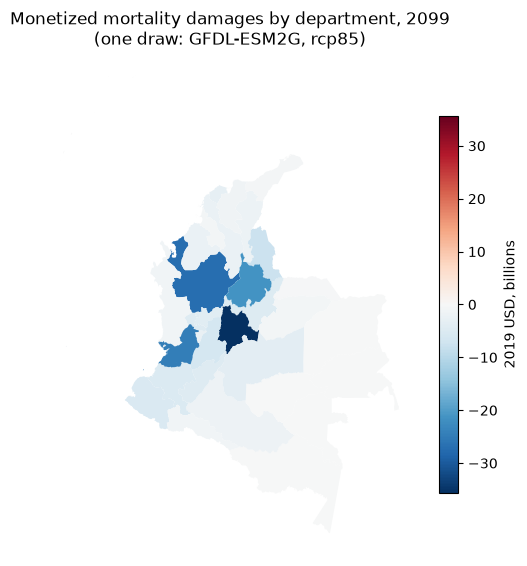

In [4]:
m = shapes.merge(d99, on=["ISO", "ID_1"])
m["billions"] = m["total_damages"] / 1e9
ax = m.plot(column="billions", legend=True, cmap="RdBu_r",
            norm=zero_centered(m["billions"]), figsize=(6, 7),
            legend_kwds={"label": "2019 USD, billions", "shrink": 0.7})
ax.set_title("Monetized mortality damages by department, 2099\n(one draw: GFDL-ESM2G, rcp85)")
ax.set_axis_off()

## Percent of GDP

Dollar totals mostly track population. To compare departments, divide
by GDP: the `ratio` kind aggregates damages and GDP as totals and
divides after, per department. The GDP is embedded in the same
projection files as the damages, so both sides of the ratio use the
same socioeconomic version.

In [5]:
both = cilreg.read_netcdf_leaf(
    damages_leaf("GFDL-ESM2G"),
    variables=["total_damages", "gdp"], region_dim="region", region_col="hierid",
)

pct = cilreg.apply_weights(
    weights, both,
    kind="ratio", weight="pop",
    value_col="total_damages", denominator_col="gdp",
    data_version=DATA_VERSION, restrict_to_sources=col_regions,
).frame

p99 = pct[pct["year"] == 2099].copy()
p99["pct_gdp"] = p99["total_damages"] * 100
p99.merge(names, on=["ISO", "ID_1"])[["NAME_1", "pct_gdp"]].sort_values("pct_gdp").head(5)

,NAME_1,pct_gdp
26,Santander,-18.232679
21,Norte de Santander,-16.466663
29,Valle del Cauca,-15.017105
28,Tolima,-13.061152
19,Meta,-13.037557


## Statistics across draws

Each draw is aggregated to departments first; the statistics are
calculated across the aggregated draws. Here the 33 climate models are
the draws, averaged over 2080 to 2099 and then pooled.

In [6]:
usd_frames, pct_frames = [], []
for gcm in GCMS:
    both_g = cilreg.read_netcdf_leaf(
        damages_leaf(gcm), variables=["total_damages", "gdp"],
        region_dim="region", region_col="hierid",
    )
    usd = cilreg.apply_weights(
        weights, both_g[["hierid", "year", "total_damages"]],
        kind="extensive", weight="pop", value_col="total_damages",
        data_version=DATA_VERSION, restrict_to_sources=col_regions,
    )
    ratio = cilreg.apply_weights(
        weights, both_g,
        kind="ratio", weight="pop",
        value_col="total_damages", denominator_col="gdp",
        data_version=DATA_VERSION, restrict_to_sources=col_regions,
    )
    usd_frames.append(usd.frame.assign(gcm=gcm))
    pct_frames.append(ratio.frame.assign(gcm=gcm))
usd_draws = pd.concat(usd_frames, ignore_index=True)
pct_draws = pd.concat(pct_frames, ignore_index=True)

stats_usd = cilreg.summarize_samples(
    usd_draws, sample_dims=["gcm"], time_col="year", window=(2080, 2099),
    value_col="total_damages", quantiles=[0.05, 0.5, 0.95],
)
stats_pct = cilreg.summarize_samples(
    pct_draws[["ISO", "ID_1", "year", "total_damages", "gcm"]],
    sample_dims=["gcm"], time_col="year",
    window=(2080, 2099), value_col="total_damages",
    quantiles=[0.05, 0.5, 0.95],
)
stats_usd.merge(names, on=["ISO", "ID_1"]).query("NAME_1 == 'Antioquia'")

,ISO,ID_1,statistic,total_damages,NAME_1
1,COL,2,mean,-1.270419e+10,Antioquia
33,COL,2,q05,-4.270336e+10,Antioquia
65,COL,2,q50,-1.524614e+10,Antioquia
97,COL,2,q95,2.302501e+10,Antioquia


## One draw against a pooled quantile

Left: the single cool draw, negative everywhere. Right: the 95th
percentile across the 33 models, positive everywhere. One model gives
one arbitrary picture.

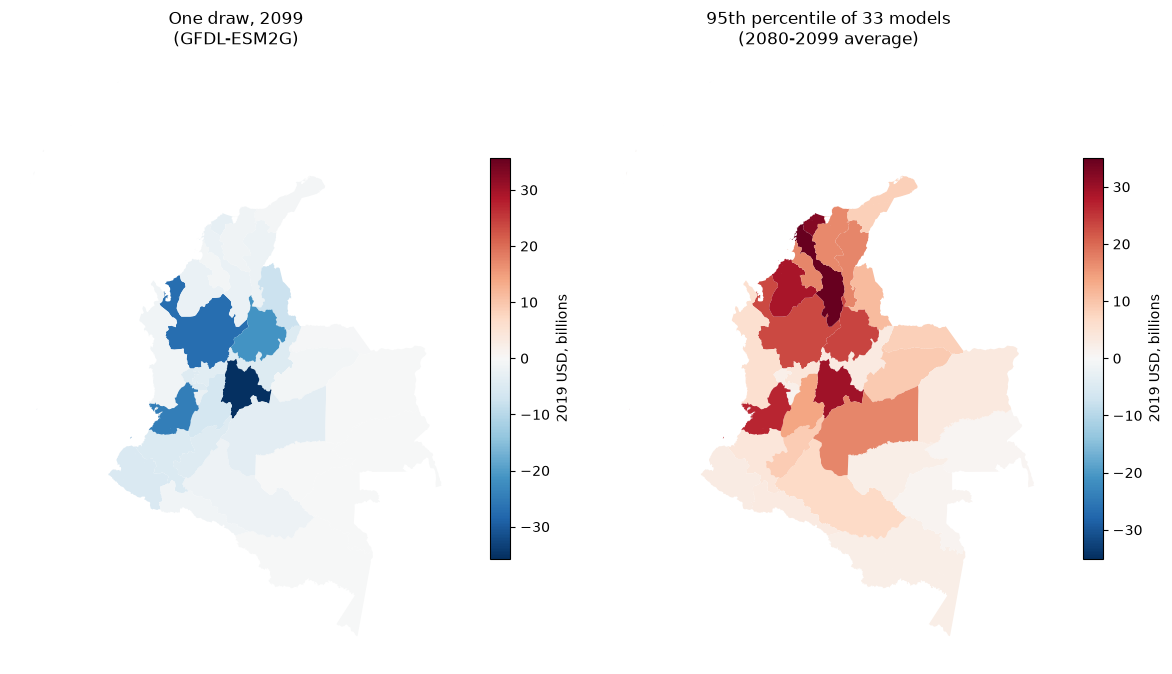

In [7]:
q95 = stats_usd[stats_usd["statistic"] == "q95"].copy()
q95["billions"] = q95["total_damages"] / 1e9

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
m.plot(column="billions", legend=True, cmap="RdBu_r",
       norm=zero_centered(m["billions"]), ax=axes[0],
       legend_kwds={"label": "2019 USD, billions", "shrink": 0.6})
axes[0].set_title("One draw, 2099\n(GFDL-ESM2G)")
mq = shapes.merge(q95, on=["ISO", "ID_1"])
mq.plot(column="billions", legend=True, cmap="RdBu_r",
        norm=zero_centered(mq["billions"]), ax=axes[1],
        legend_kwds={"label": "2019 USD, billions", "shrink": 0.6})
axes[1].set_title("95th percentile of 33 models\n(2080-2099 average)")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()

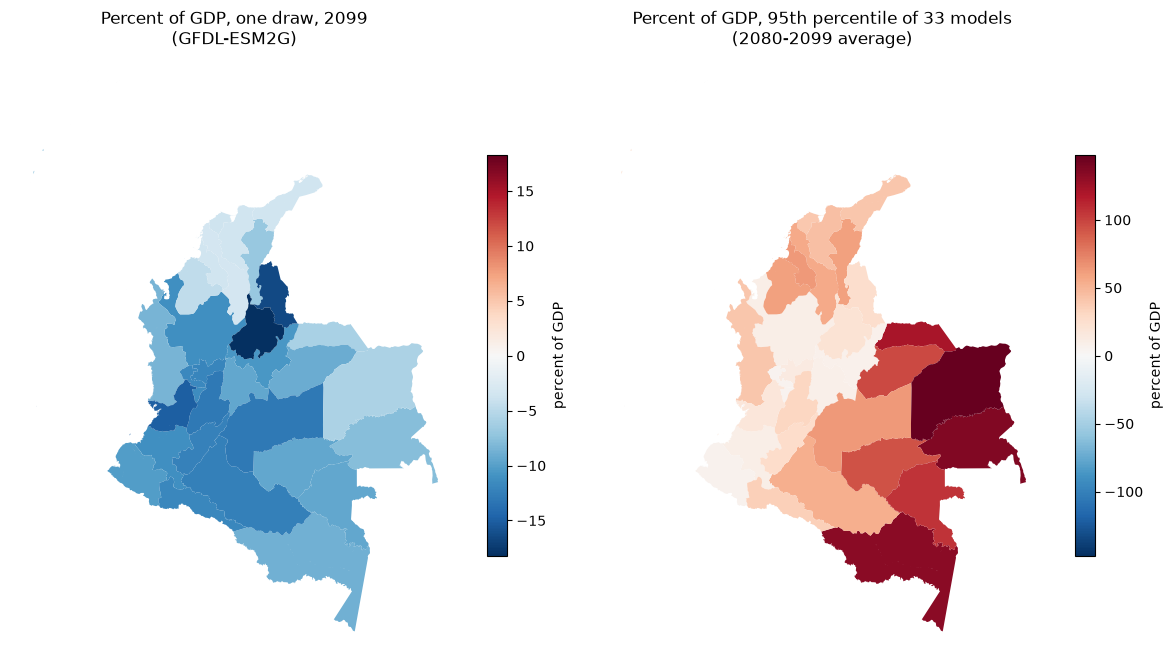

In [8]:
pq95 = stats_pct[stats_pct["statistic"] == "q95"].copy()
pq95["pct_gdp"] = pq95["total_damages"] * 100
mp = shapes.merge(p99, on=["ISO", "ID_1"])
mpq = shapes.merge(pq95, on=["ISO", "ID_1"])

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
mp.plot(column="pct_gdp", legend=True, cmap="RdBu_r",
        norm=zero_centered(mp["pct_gdp"]), ax=axes[0],
        legend_kwds={"label": "percent of GDP", "shrink": 0.6})
axes[0].set_title("Percent of GDP, one draw, 2099\n(GFDL-ESM2G)")
mpq.plot(column="pct_gdp", legend=True, cmap="RdBu_r",
         norm=zero_centered(mpq["pct_gdp"]), ax=axes[1],
         legend_kwds={"label": "percent of GDP", "shrink": 0.6})
axes[1].set_title("Percent of GDP, 95th percentile of 33 models\n(2080-2099 average)")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout()

## The spread of draws by department

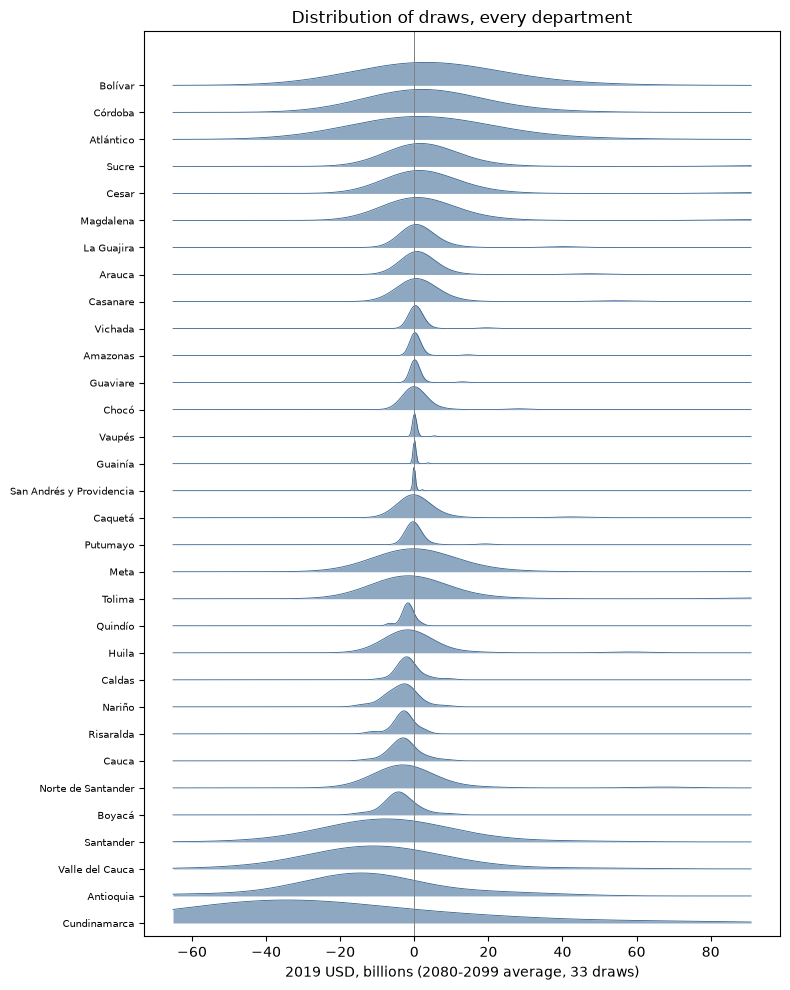

In [9]:
wmeans = (usd_draws[usd_draws["year"].between(2080, 2099)]
          .groupby(["ISO", "ID_1", "gcm"])["total_damages"].mean().reset_index()
          .merge(names, on=["ISO", "ID_1"]))
wmeans["billions"] = wmeans["total_damages"] / 1e9

order = (wmeans.groupby("NAME_1")["billions"].median()
         .sort_values().index.tolist())
lo, hi = wmeans["billions"].quantile([0.01, 0.99])
xs = np.linspace(lo * 1.3, hi * 1.3, 400)

fig, ax = plt.subplots(figsize=(8, 10))
for i, name in enumerate(order):
    vals = wmeans.loc[wmeans["NAME_1"] == name, "billions"].to_numpy()
    bw = max(1.06 * vals.std(ddof=1) * len(vals) ** (-1 / 5), 1e-6)
    dens = np.exp(-0.5 * ((xs[:, None] - vals[None, :]) / bw) ** 2).sum(1)
    dens = dens / dens.max() * 0.85
    ax.fill_between(xs, i, i + dens, color="#33628f", alpha=0.55, lw=0)
    ax.plot(xs, i + dens, color="#33628f", lw=0.6)
ax.axvline(0, color="gray", lw=0.7)
ax.set_yticks(range(len(order)), order, fontsize=7)
ax.set_xlabel("2019 USD, billions (2080-2099 average, 33 draws)")
ax.set_title("Distribution of draws, every department")
ax.set_ylim(-0.5, len(order) + 1)
plt.tight_layout()

## Other levels

The same operation works at any level; only the weight file changes.
At country level Colombia is a single unit, so the total is the sum
over departments; an ADM0 weight file would do this with coarser
weights.

In [10]:
print(f"Colombia total, 2099, one draw: {d99['total_damages'].sum() / 1e9:.1f} billion 2019 USD")

Colombia total, 2099, one draw: -177.4 billion 2019 USD


At municipality level (ADM2) the finer weight file does more work: a
Colombian impact region is a group of municipalities, and one region's
total can spread across as many as 90 of them. The totals still add
back up, and the distribution of draws looks different: 1,065 smaller
units concentrate near zero with long tails, where 32 departments
spread wide.

In [11]:
weights_adm2 = cilreg.fetch_weights("gadm20-adm2-per-source")

adm2_frames = []
for gcm in GCMS:
    data = cilreg.read_netcdf_leaf(damages_leaf(gcm), variables=["total_damages"],
                                   region_dim="region", region_col="hierid",
                                   kind="extensive")
    applied = cilreg.apply_weights(
        weights_adm2, data, kind="extensive", weight="pop",
        value_col="total_damages", data_version=DATA_VERSION,
        restrict_to_sources=col_regions,
    )
    adm2_frames.append(applied.frame.assign(gcm=gcm))
adm2_draws = pd.concat(adm2_frames, ignore_index=True)

a99 = adm2_draws[(adm2_draws["year"] == 2099) & (adm2_draws["gcm"] == "GFDL-ESM2G")]
print(f"municipalities: {len(a99)}")
print(f"sum over municipalities: {a99['total_damages'].sum():.6e}")
print(f"sum over departments:    {d99['total_damages'].sum():.6e}")

municipalities: 1065
sum over municipalities: -1.774214e+11
sum over departments:    -1.774214e+11


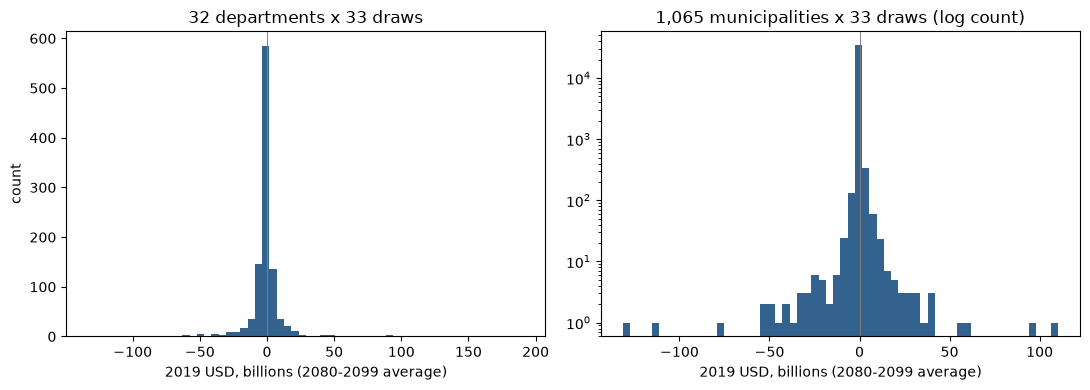

In [12]:
w1 = (usd_draws[usd_draws["year"].between(2080, 2099)]
      .groupby(["ID_1", "gcm"])["total_damages"].mean() / 1e9)
w2 = (adm2_draws[adm2_draws["year"].between(2080, 2099)]
      .groupby(["ID_1", "ID_2", "gcm"])["total_damages"].mean() / 1e9)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
axes[0].hist(w1, bins=60, color="#33628f")
axes[0].set_title(f"32 departments x 33 draws")
axes[1].hist(w2, bins=60, color="#33628f")
axes[1].set_yscale("log")
axes[1].set_title(f"1,065 municipalities x 33 draws (log count)")
for ax in axes:
    ax.set_xlabel("2019 USD, billions (2080-2099 average)")
    ax.axvline(0, color="gray", lw=0.7)
axes[0].set_ylabel("count")
plt.tight_layout()

## Other variable types

Rates, like deaths per person per year, are averages rather than
totals; they use the `per_destination` weights, which average over the
regions inside each unit. The script next to this notebook,
`run_example.py`, runs the rates at both levels and has an `--offline`
mode. Its rates sample is different (two batches of one model),
because the tree holding the rates is still being regenerated.